### This notebook compute "VSS7. Index of annual electricity consumption" indicator for the 27 basins of IKI Project

Spanish: Índice del consumo anual de energía eléctrica

**Created:** 12/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**  1/21/2026 by Sophia Bakar
**Status:**  Complete and loaded into the SQL database for the baseline and first future scenario.
**QA Status:** reviewed by Scott Sheeder  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Objective:**   
**Compatibility:** 
**Packages:** numpy, pandas, geopandas, sqlite3, matplotlib ...  
**Further documentation:**  
 
**Inputs:**   Shapefile of COMIDs and districts, electricity consumption comes from MINEM Pg. 1 of 'Capitulo 2 Estadisitica por Regiones 2024' PDF ( https://www.gob.pe/institucion/minem/informes-publicaciones/7324144-anuario-estadistico-de-electricidad-2024). I then converted to an excel using Adobe Acrobat 2020. Poblacion por distrito comes from https://estadist.inei.gob.pe/report . I selected the report view and then downloaded the table which has the population for all years for all districts. I used the year that matches the anuario which in this case is 2024. 

**Formula:** 
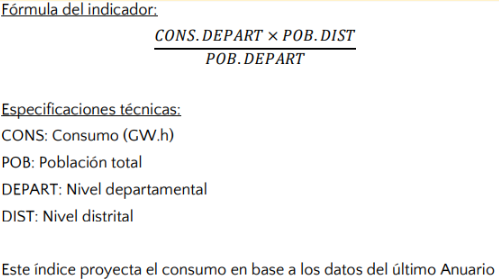
 
**Assumptions:** Using weighted method to map district value to subbasins. 
 
**Future work:** Modify for weighted method as opposed to majority. Update if we get future projections of population

**Notes:** 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'nreynolds'
#user = 'sbakar'
#user = 'ssheeder'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 407 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

# districts = fr'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/COMID_District_Fractions.csv'
districts = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\COMID_District_Fractions.csv"

# consumo = fr'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/Capitulo-2-estadistica-por-regiones-2024.xlsx'
consumo = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad\Capitulo-2-estadistica-por-regiones-2024.xlsx"

# population_census = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/VSS7_reporte_estadist.xlsx'
population_census = f"C:/Users/sbakar/OneDrive - Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/VSS7_reporte_estadist.xlsx"

In [5]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
district_area_within_COMID = pd.read_csv(districts)
consumo_depart = pd.read_excel(consumo)
poblacion_census = pd.read_excel(population_census)
year = 2024

In [6]:
#WEIGHTED METHOD FUNCTION 
def calculate_proportionate_values(district_fractions_df, value_df, column_name, comid_list):
    """
    Calculate proportionate values for each COMID based on district area fractions
    
    Parameters:
    - district_fractions_df: DataFrame with COMID, DISTRICT, district_area_within_COMID_fraction
    - value_df: DataFrame with IDDIST and indicator values
    - column_name: Name of the column containing the indicator values
    - comid_list: List of COMIDs to process
    
    Returns:
    - DataFrame with COMID and proportionate_indicator_value
    """
    # Ensure IDDIST and DISTRICT columns are in the same format
    value_df = value_df.copy()
    district_fractions_df = district_fractions_df.copy()
    
    value_df['IDDIST'] = value_df['IDDIST'].astype(str).str.strip()
    district_fractions_df['DISTRICT'] = district_fractions_df['DISTRICT'].astype(str).str.strip()
    
    results = []
    
    for comid in comid_list:
        # Get all districts within this COMID
        districts_in_comid = district_fractions_df[district_fractions_df['COMID'] == comid]
        
        total_proportionate_value = 0
        
        for _, row in districts_in_comid.iterrows():
            district_id = row['DISTRICT']
            fraction = row['district_area_within_COMID_fraction']
            # Get the indicator value for this district
            ind_value = value_df[value_df['IDDIST'] == district_id][column_name].values

            if len(ind_value) > 0:
                # Multiply district value by the fraction of area within COMID
                proportionate_value = ind_value[0] * fraction
                total_proportionate_value += proportionate_value
        
        results.append({
            'COMID': comid,
            'proportionate_indicator_value': total_proportionate_value
        })
    
    return pd.DataFrame(results)

In [7]:
#FORMATTING THE DF

#make the second row the headers
new_header = consumo_depart.iloc[1] #grab the first row for the header
consumo_depart = consumo_depart[2:] #take the data less the header row
consumo_depart.columns = new_header #set the header row as the dataframe header
#remove second row, keep in mind units of energy are Gwh(2) and electrica per capita are kWh/hab
consumo_depart = consumo_depart.drop(consumo_depart.index[0])
#rename NaN column as 'Departamento'
consumo_depart= consumo_depart.rename(columns={np.nan: 'Departamento'})
# Remove rows where 'TOTAL' or 'Fuente' appear anywhere in the Departamento column (case-insensitive)
consumo_depart = consumo_depart[~consumo_depart['Departamento'].str.contains('TOTAL|Fuente', case=False, na=False)]

#in the column {habitantes), remove all spaces and convert to numeric
consumo_depart['(habitantes)'] = consumo_depart['(habitantes)'].str.replace(' ', '').astype(float)
#in the column, Energia Electrica, remove all spaces and commas and convert to numeric 
consumo_depart['Energía Eléctrica'] = consumo_depart['Energía Eléctrica'].str.replace(' ', '').str.replace(',', '').astype(float)

# Replace header only for columns where the first row has a non-NaN value
new_header = poblacion_census.iloc[0]
for col_idx, val in enumerate(new_header):
    if pd.notna(val):
        poblacion_census.columns.values[col_idx] = val

# Remove the first row after replacing headers
poblacion_census = poblacion_census[1:].reset_index(drop=True)

In [8]:
#CALCULATE POPULATION

# Version 1: Population by Departamento for 2024
poblacion_depart = poblacion_census.groupby('Departamento')[year].sum().reset_index()
poblacion_depart = poblacion_depart.rename(columns={year: f'Poblacion_{year}'})

print("Population by Departamento:")
print(poblacion_depart)

# Version 2: Population by Distrito for 2024
poblacion_distrito = poblacion_census[['Ubigeo', 'Distrito', year]].copy()
poblacion_distrito = poblacion_distrito.rename(columns={year: f'Poblacion_{year}'})

print("\nPopulation by Distrito:")
print(poblacion_distrito)


Population by Departamento:
     Departamento  Poblacion_2024
0        AMAZONAS          430123
1          ANCASH         1202171
2        APURIMAC          426626
3        AREQUIPA         1605569
4        AYACUCHO          669737
5       CAJAMARCA         1447707
6          CALLAO         1209614
7           CUSCO         1398036
8    HUANCAVELICA          335142
9         HUANUCO          746509
10            ICA         1062346
11          JUNIN         1380561
12    LA LIBERTAD         2130145
13     LAMBAYEQUE         1361554
14           LIMA        11304993
15         LORETO         1057592
16  MADRE DE DIOS          197096
17       MOQUEGUA          201129
18          PASCO          265392
19          PIURA         2149978
20           PUNO         1208802
21     SAN MARTIN          945523
22          TACNA          396180
23         TUMBES          266653
24        UCAYALI          639279

Population by Distrito:
        Ubigeo    Distrito  Poblacion_2024
0      10202.0    AR

In [9]:
#MAPPING DISTRICTS TO DEPARTMENTS AND CALCULATING INDICATOR

# Create a dictionary mapping Distrito to Departamento
distrito_to_departamento = poblacion_census.set_index('Distrito')['Departamento'].to_dict()

print("District to Department mapping:")
print(f"Total districts: {len(distrito_to_departamento)}")
print("\nSample mappings:")
for distrito, departamento in list(distrito_to_departamento.items())[:5]:
    print(f"{distrito} -> {departamento}")

# For each district, calculate weighted energy consumption
# Step 1: Add Departamento to poblacion_distrito using the dictionary
poblacion_distrito['Departamento'] = poblacion_distrito['Distrito'].map(distrito_to_departamento)

# Step 2: Merge energy consumption by department
poblacion_distrito = poblacion_distrito.merge(
    consumo_depart[['Departamento', 'Energía Eléctrica']], 
    on='Departamento', 
    how='left'
)

# Step 3: Merge population by department
poblacion_distrito = poblacion_distrito.merge(
    poblacion_depart[['Departamento', f'Poblacion_{year}']], 
    on='Departamento', 
    how='left',
    suffixes=('_distrito', '_depart')
)

# Step 4: Calculate weighted energy consumption per district
# Formula: (Energy_Dept * Pop_District) / Pop_Dept
poblacion_distrito['Consumo_distrito'] = (
    poblacion_distrito['Energía Eléctrica'] * 
    poblacion_distrito[f'Poblacion_{year}_distrito']
) / poblacion_distrito[f'Poblacion_{year}_depart']

print("Energy consumption per district:")
print(poblacion_distrito[['Ubigeo', 'Distrito', 'Departamento', 'Consumo_distrito']].head(10))

# Prepare data for weighted method function
# Ensure Ubigeo has the correct format (6 digits, no decimals)
poblacion_distrito['Ubigeo'] = poblacion_distrito['Ubigeo'].astype(str).str.zfill(6).str.split('.').str[0]
poblacion_distrito = poblacion_distrito.rename(columns={'Ubigeo': 'IDDIST'})

District to Department mapping:
Total districts: 1735

Sample mappings:
ARAMANGO -> AMAZONAS
BAGUA -> AMAZONAS
COPALLIN -> AMAZONAS
EL PARCO -> AMAZONAS
IMAZA -> AMAZONAS
Energy consumption per district:
    Ubigeo    Distrito Departamento  Consumo_distrito
0  10202.0    ARAMANGO     AMAZONAS        257.063040
1  10201.0       BAGUA     AMAZONAS        823.361178
2  10203.0    COPALLIN     AMAZONAS        112.660625
3  10204.0    EL PARCO     AMAZONAS         33.453226
4  10205.0       IMAZA     AMAZONAS        915.618277
5  10206.0     LA PECA     AMAZONAS        166.490636
6  10302.0  CHISQUILLA     AMAZONAS          8.236286
7  10303.0     CHURUJA     AMAZONAS          7.808427
8  10304.0     COROSHA     AMAZONAS         22.703269
9  10305.0     CUISPES     AMAZONAS         17.060878


In [13]:
#MAP VALUE TO SUBBASINS USING WEIGHTED METHOD

# Get unique COMIDs from subbasins_gdf
unique_comids = subbasins_gdf['COMID'].unique()

# Calculate proportionate values using weighted method
proportionate_df = calculate_proportionate_values(
    district_area_within_COMID, 
    poblacion_distrito, 
    'Consumo_distrito',
    unique_comids
)

# Merge back to subbasins_gdf
subbasins_gdf = subbasins_gdf.merge(
    proportionate_df, 
    on='COMID', 
    how='left'
)

# Rename column and round to 2 decimal places
subbasins_gdf = subbasins_gdf.rename(columns={'proportionate_indicator_value': 'Consumo_distrito'})
subbasins_gdf['Consumo_distrito'] = subbasins_gdf['Consumo_distrito'].round(2)
subbasins_gdf = subbasins_gdf.loc[:, ~subbasins_gdf.columns.duplicated(keep='last')]
subbasins_gdf.loc[subbasins_gdf['Consumo_distrito'] == 0,'Consumo_distrito'] = np.nan

# Display results
print("Sample of proportionate energy consumption values:")
print(subbasins_gdf[['COMID', 'Consumo_distrito']].head(10))
print(f"\nTotal COMIDs: {len(subbasins_gdf)}")
print(f"COMIDs with energy consumption data (>0): {(subbasins_gdf['Consumo_distrito'] > 0).sum()}")
print(f"COMIDs without energy consumption data (=NaN): {(subbasins_gdf['Consumo_distrito'].isna()).sum()}")

Sample of proportionate energy consumption values:
       COMID  Consumo_distrito
0  311153600            170.44
1  310832400            791.45
2  310825700           1971.58
3  310282400           8657.91
4  308754600            607.99
5  307736500            291.13
6  307078200            176.81
7  307183500            245.57
8  306538400            679.88
9  306599700               NaN

Total COMIDs: 3655
COMIDs with energy consumption data (>0): 2912
COMIDs without energy consumption data (=NaN): 743


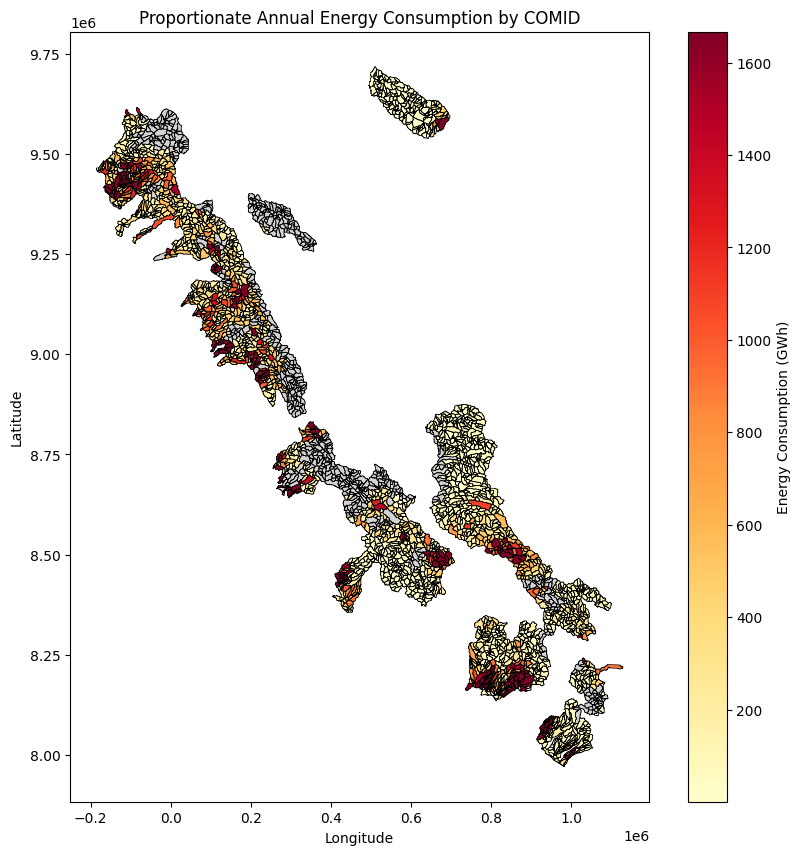

In [15]:
#VISUALIZE 
# Compute quantile-based limits
vmin = nonzero_values['Consumo_distrito'].quantile(0.05)
vmax = nonzero_values['Consumo_distrito'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot NaN / zero as grey (note: you already converted 0 → NaN earlier)
subbasins_gdf[subbasins_gdf['Consumo_distrito'].isna()].plot(
    ax=ax,
    color='lightgrey',
    edgecolor='black',
    linewidth=0.5,
    label='No Data'
)

# Plot values with scaled colorbar
nonzero_values.plot(
    column='Consumo_distrito',
    ax=ax,
    cmap='YlOrRd',
    vmin=vmin,
    vmax=vmax,
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': 'Energy Consumption (GWh)'}
)

ax.set_title('Proportionate Annual Energy Consumption by COMID')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()


Number of unique districts (IDDIST) with energy consumption data: 1891
Number of unique districts in COMID_District_Fractions: 1299
Districts with matching data: 1299 out of 1299
Match rate: 100.00%
Districts without data: 0

Energy Consumption by COMID - Summary Statistics:
count      2912.000000
mean        714.186442
std        5863.209524
min           0.020000
25%          14.625000
50%          72.495000
75%         269.917500
max      173045.380000
Name: Consumo_distrito, dtype: float64


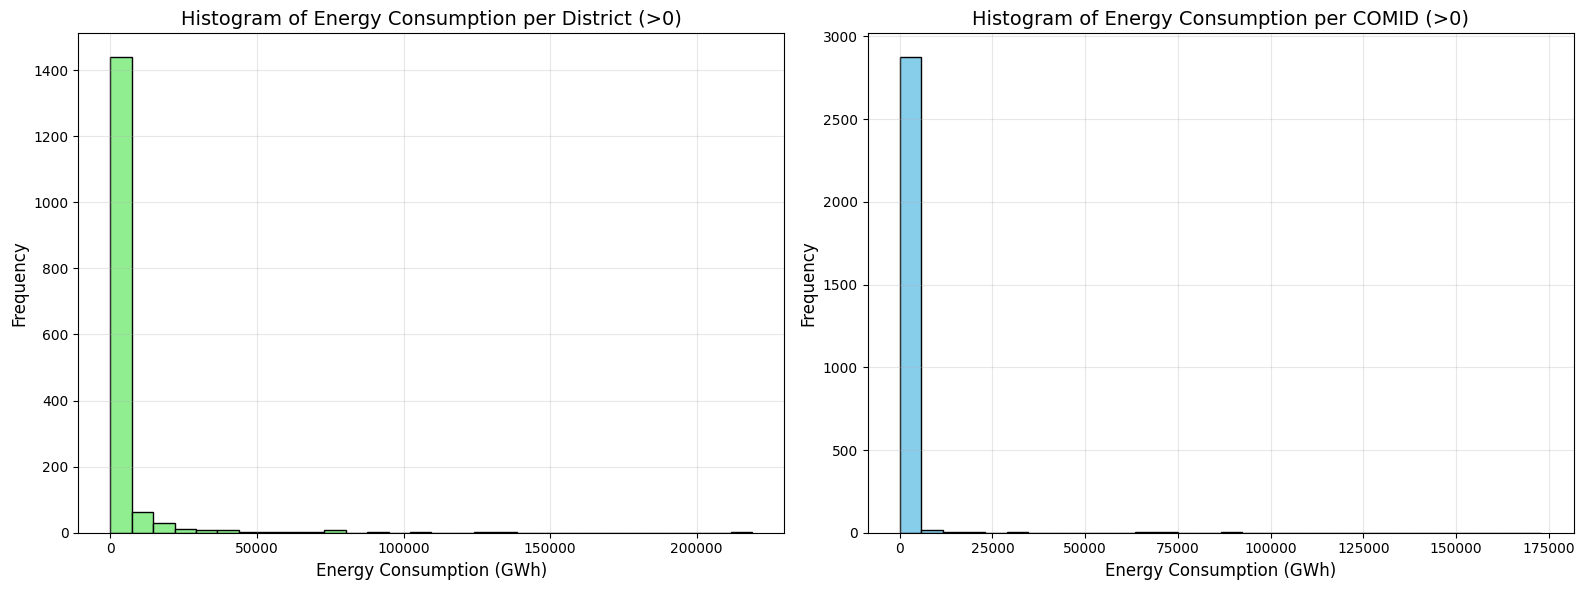


Districts with energy consumption > 0: 1576
COMIDs with energy consumption > 0: 2912


In [16]:
#QUALITY CONTROL

# Summarize number of districts with energy consumption data
unique_iddist_with_data = poblacion_distrito['IDDIST'].nunique()
unique_iddist_in_fractions = district_area_within_COMID['DISTRICT'].nunique()

print(f"\nNumber of unique districts (IDDIST) with energy consumption data: {unique_iddist_with_data}")
print(f"Number of unique districts in COMID_District_Fractions: {unique_iddist_in_fractions}")

# Check which districts in fractions file have matching data
districts_in_fractions = set(district_area_within_COMID['DISTRICT'].astype(str).str.strip())
districts_with_data = set(poblacion_distrito['IDDIST'].astype(str).str.strip())
matched_districts = districts_in_fractions.intersection(districts_with_data)
unmatched_districts = districts_in_fractions - districts_with_data

print(f"Districts with matching data: {len(matched_districts)} out of {len(districts_in_fractions)}")
print(f"Match rate: {(len(matched_districts) / len(districts_in_fractions) * 100):.2f}%")
print(f"Districts without data: {len(unmatched_districts)}")

# Summary statistics for energy consumption by COMID
print("\nEnergy Consumption by COMID - Summary Statistics:")
print(subbasins_gdf['Consumo_distrito'].describe())

# Histogram of energy consumption per district (excluding zeros)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# District-level histogram
non_zero_districts = poblacion_distrito[poblacion_distrito['Consumo_distrito'] > 0]['Consumo_distrito']
ax1.hist(non_zero_districts, bins=30, color='lightgreen', edgecolor='black')
ax1.set_title('Histogram of Energy Consumption per District (>0)', fontsize=14)
ax1.set_xlabel('Energy Consumption (GWh)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.grid(True, alpha=0.3)

# COMID-level histogram
non_zero_comids = subbasins_gdf[subbasins_gdf['Consumo_distrito'] > 0]['Consumo_distrito']
ax2.hist(non_zero_comids, bins=30, color='skyblue', edgecolor='black')
ax2.set_title('Histogram of Energy Consumption per COMID (>0)', fontsize=14)
ax2.set_xlabel('Energy Consumption (GWh)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDistricts with energy consumption > 0: {len(non_zero_districts)}")
print(f"COMIDs with energy consumption > 0: {len(non_zero_comids)}")

# Show sample of unmatched districts if any exist
if len(unmatched_districts) > 0:
    print(f"\nSample of unmatched districts (first 10):")
    for dist in list(unmatched_districts)[:10]:
        print(f"  {dist}")

COMPARISON: Weighted Method vs. Direct IDDIST Mapping Method

Total COMIDs: 3655

Weighted Method:
  Total energy consumption: 2,079,710.92 GWh
  Average per COMID: 714.19 GWh
  Median per COMID: 72.50 GWh
  COMIDs with data (>0): 2912

Direct IDDIST Mapping Method:
  Total energy consumption: 9,211,986.80 GWh
  Average per COMID: 2,585.46 GWh
  Median per COMID: 551.92 GWh
  COMIDs with data (>0): 3164

Difference (Weighted - Direct):
  Total difference: -6,364,576.77 GWh
  Average difference: -2,185.64 GWh
  Median difference: -544.16 GWh
  Std deviation: 8,731.63 GWh
  COMIDs with higher weighted values: 231
  COMIDs with lower weighted values: 2681
  COMIDs with same values: 0

Top 10 COMIDs with Largest Absolute Differences:
    COMID  Weighted_Consumo  Direct_Consumo    Difference  Percent_Difference
309352600         173045.38     8150.897073 164894.482927         2023.022515
310058100         105109.90    11464.808783  93645.091217          816.804650
311332800          70919.6

C:\Users\sbakar\AppData\Local\Temp\ipykernel_28668\340388357.py:86: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  zero_w.plot(ax=ax1, color='lightgrey', edgecolor='black', linewidth=0.5)


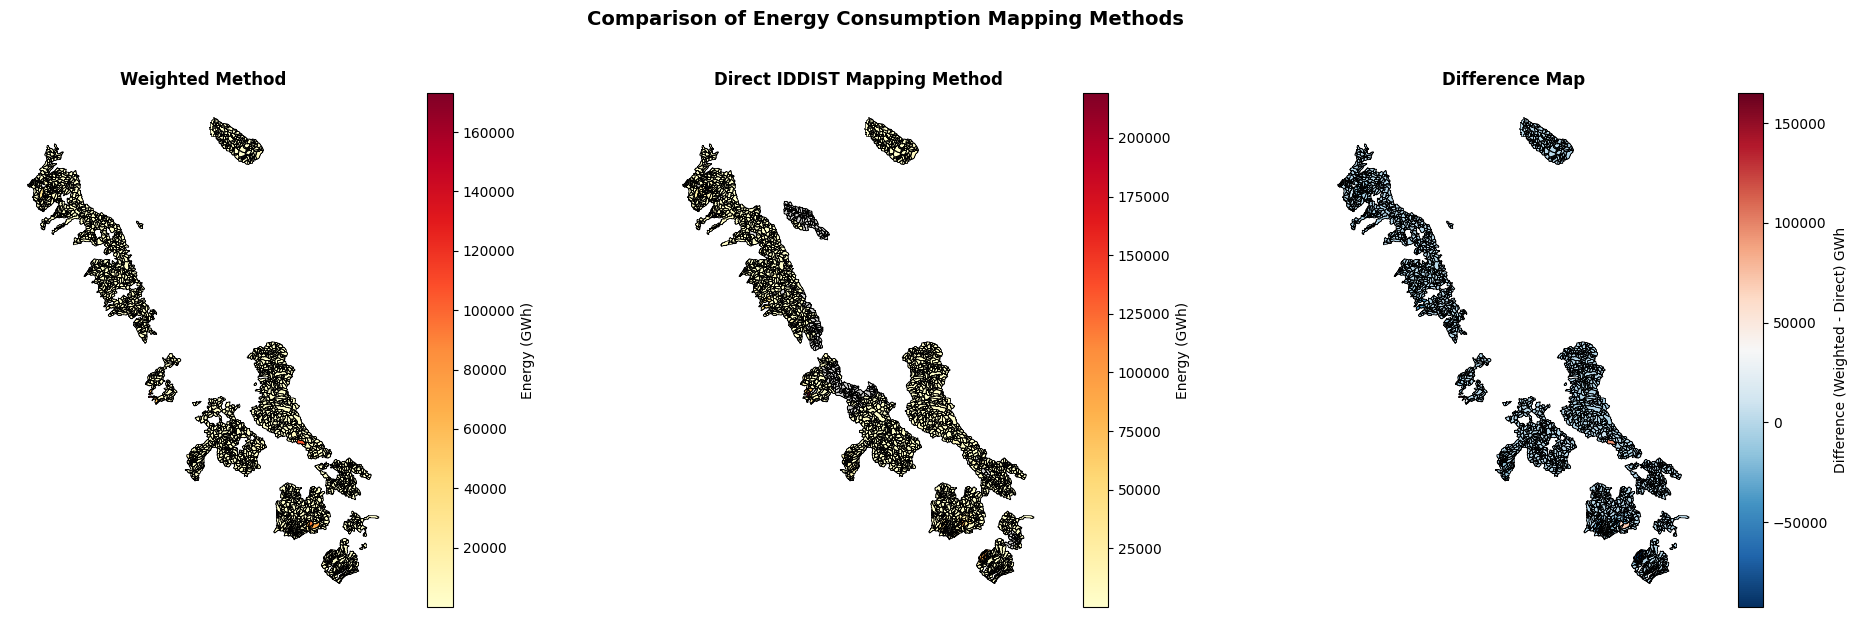

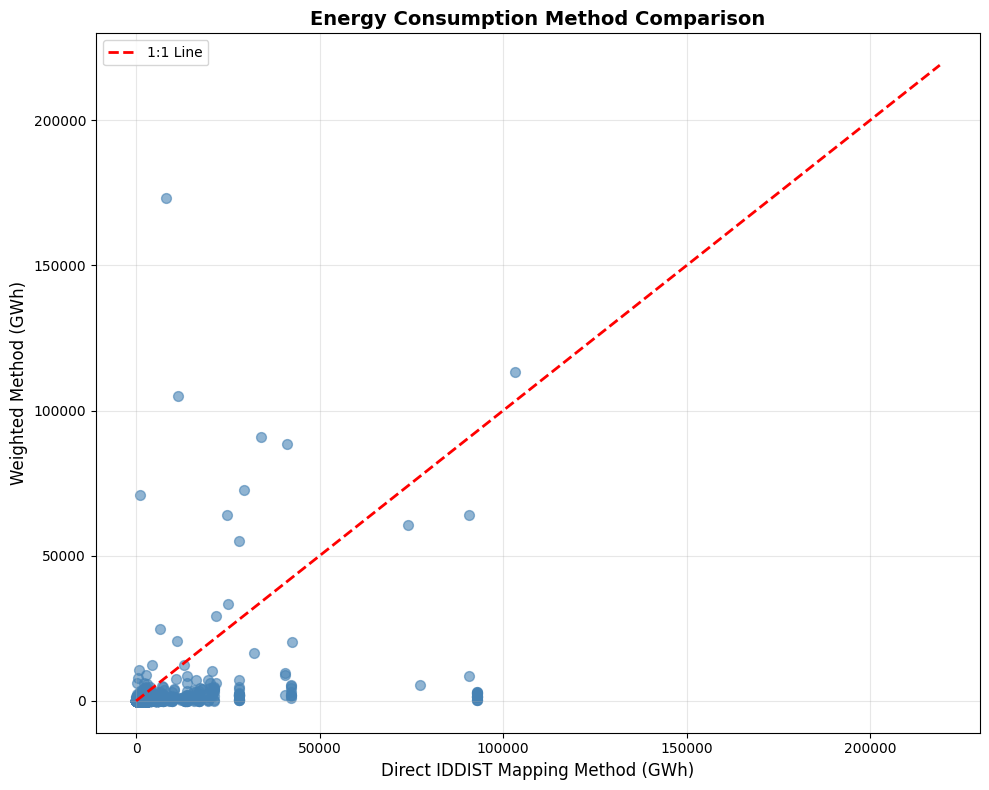

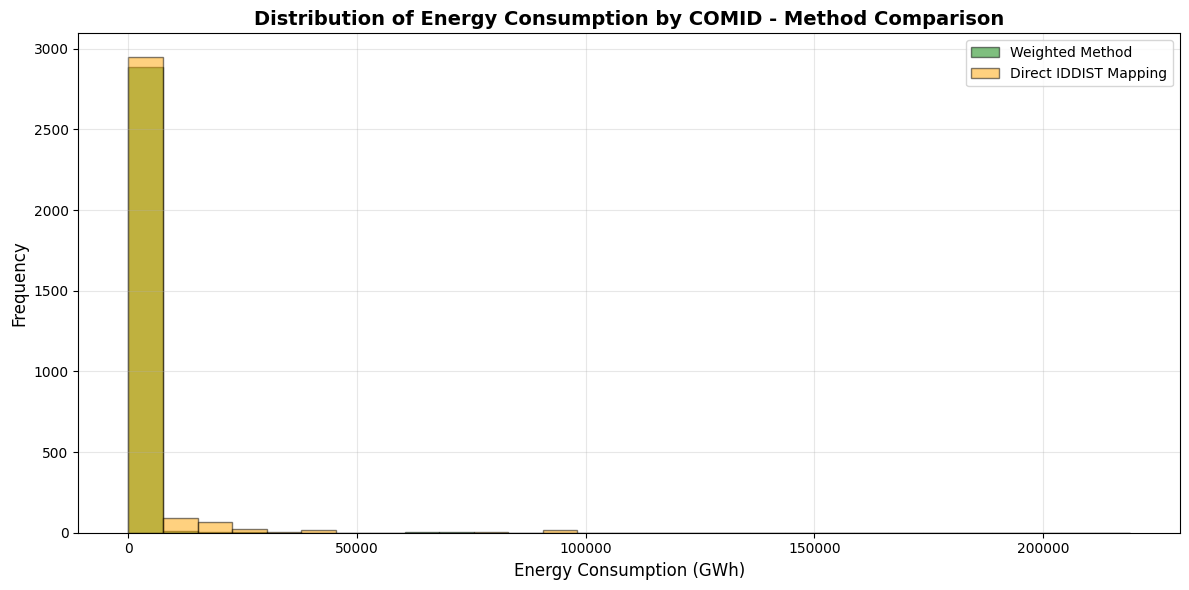

In [17]:
# Create comparison between weighted method and direct IDDIST mapping method

# Method 1: Weighted/Proportionate method (already calculated)
weighted_totals = subbasins_gdf[['COMID', 'Consumo_distrito']].copy()
weighted_totals = weighted_totals.rename(columns={'Consumo_distrito': 'Weighted_Consumo'})

# Method 2: Direct IDDIST mapping method
# Map each COMID to its corresponding IDDIST (using the district with largest area fraction)
comid_to_iddist = district_area_within_COMID.loc[
    district_area_within_COMID.groupby('COMID')['district_area_within_COMID_fraction'].idxmax()
][['COMID', 'DISTRICT']]

# Ensure DISTRICT format matches IDDIST in poblacion_distrito
comid_to_iddist['DISTRICT'] = comid_to_iddist['DISTRICT'].astype(str).str.strip()

# Merge with energy consumption data
direct_mapping = comid_to_iddist.merge(
    poblacion_distrito[['IDDIST', 'Consumo_distrito']],
    left_on='DISTRICT',
    right_on='IDDIST',
    how='left'
)
direct_mapping = direct_mapping[['COMID', 'Consumo_distrito']].rename(
    columns={'Consumo_distrito': 'Direct_Consumo'}
)
direct_mapping['Direct_Consumo'] = direct_mapping['Direct_Consumo'].fillna(0)

# Merge both methods for comparison
comparison_df = weighted_totals.merge(direct_mapping, on='COMID', how='left')
comparison_df['Difference'] = comparison_df['Weighted_Consumo'] - comparison_df['Direct_Consumo']
comparison_df['Percent_Difference'] = np.where(
    comparison_df['Direct_Consumo'] > 0,
    (comparison_df['Difference'] / comparison_df['Direct_Consumo']) * 100,
    np.nan
)

# Summary statistics
print("=" * 80)
print("COMPARISON: Weighted Method vs. Direct IDDIST Mapping Method")
print("=" * 80)
print(f"\nTotal COMIDs: {len(comparison_df)}")
print(f"\nWeighted Method:")
print(f"  Total energy consumption: {comparison_df['Weighted_Consumo'].sum():,.2f} GWh")
print(f"  Average per COMID: {comparison_df['Weighted_Consumo'].mean():,.2f} GWh")
print(f"  Median per COMID: {comparison_df['Weighted_Consumo'].median():,.2f} GWh")
print(f"  COMIDs with data (>0): {(comparison_df['Weighted_Consumo'] > 0).sum()}")
print(f"\nDirect IDDIST Mapping Method:")
print(f"  Total energy consumption: {comparison_df['Direct_Consumo'].sum():,.2f} GWh")
print(f"  Average per COMID: {comparison_df['Direct_Consumo'].mean():,.2f} GWh")
print(f"  Median per COMID: {comparison_df['Direct_Consumo'].median():,.2f} GWh")
print(f"  COMIDs with data (>0): {(comparison_df['Direct_Consumo'] > 0).sum()}")
print(f"\nDifference (Weighted - Direct):")
print(f"  Total difference: {comparison_df['Difference'].sum():,.2f} GWh")
print(f"  Average difference: {comparison_df['Difference'].mean():,.2f} GWh")
print(f"  Median difference: {comparison_df['Difference'].median():,.2f} GWh")
print(f"  Std deviation: {comparison_df['Difference'].std():,.2f} GWh")
print(f"  COMIDs with higher weighted values: {(comparison_df['Difference'] > 0).sum()}")
print(f"  COMIDs with lower weighted values: {(comparison_df['Difference'] < 0).sum()}")
print(f"  COMIDs with same values: {(comparison_df['Difference'] == 0).sum()}")

# Display sample of largest differences
print("\n" + "=" * 80)
print("Top 10 COMIDs with Largest Absolute Differences:")
print("=" * 80)
top_diff = comparison_df.nlargest(10, 'Difference')[
    ['COMID', 'Weighted_Consumo', 'Direct_Consumo', 'Difference', 'Percent_Difference']
]
print(top_diff.to_string(index=False))

print("\n" + "=" * 80)
print("Top 10 COMIDs with Largest Negative Differences:")
print("=" * 80)
bottom_diff = comparison_df.nsmallest(10, 'Difference')[
    ['COMID', 'Weighted_Consumo', 'Direct_Consumo', 'Difference', 'Percent_Difference']
]
print(bottom_diff.to_string(index=False))

# Visualization: Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Weighted method
ax1 = axes[0]
subbasins_weighted = subbasins_gdf.merge(weighted_totals, on='COMID', how='left')
zero_w = subbasins_weighted[subbasins_weighted['Weighted_Consumo'] == 0]
nonzero_w = subbasins_weighted[subbasins_weighted['Weighted_Consumo'] > 0]
zero_w.plot(ax=ax1, color='lightgrey', edgecolor='black', linewidth=0.5)
nonzero_w.plot(column='Weighted_Consumo', ax=ax1, cmap='YlOrRd', 
               legend=True, edgecolor='black', linewidth=0.5,
               legend_kwds={'label': 'Energy (GWh)'})
ax1.set_title('Weighted Method', fontsize=12, fontweight='bold')
ax1.axis('off')

# Plot 2: Direct IDDIST mapping method
ax2 = axes[1]
subbasins_direct = subbasins_gdf.merge(direct_mapping, on='COMID', how='left')
zero_d = subbasins_direct[subbasins_direct['Direct_Consumo'] == 0]
nonzero_d = subbasins_direct[subbasins_direct['Direct_Consumo'] > 0]
zero_d.plot(ax=ax2, color='lightgrey', edgecolor='black', linewidth=0.5)
nonzero_d.plot(column='Direct_Consumo', ax=ax2, cmap='YlOrRd', 
               legend=True, edgecolor='black', linewidth=0.5,
               legend_kwds={'label': 'Energy (GWh)'})
ax2.set_title('Direct IDDIST Mapping Method', fontsize=12, fontweight='bold')
ax2.axis('off')

# Plot 3: Difference map
ax3 = axes[2]
subbasins_diff = subbasins_gdf.merge(comparison_df[['COMID', 'Difference']], on='COMID', how='left')
subbasins_diff.plot(column='Difference', ax=ax3, cmap='RdBu_r', 
                    legend=True, edgecolor='black', linewidth=0.5,
                    legend_kwds={'label': 'Difference (Weighted - Direct) GWh'})
ax3.set_title('Difference Map', fontsize=12, fontweight='bold')
ax3.axis('off')

plt.suptitle('Comparison of Energy Consumption Mapping Methods', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Scatter plot comparison
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(comparison_df['Direct_Consumo'], 
           comparison_df['Weighted_Consumo'],
           alpha=0.6, s=50, c='steelblue')
max_val = max(comparison_df['Direct_Consumo'].max(), 
              comparison_df['Weighted_Consumo'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='1:1 Line')
ax.set_xlabel('Direct IDDIST Mapping Method (GWh)', fontsize=12)
ax.set_ylabel('Weighted Method (GWh)', fontsize=12)
ax.set_title('Energy Consumption Method Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distribution comparison histogram
fig, ax = plt.subplots(figsize=(12, 6))
bins = np.linspace(0, max(comparison_df['Weighted_Consumo'].max(), 
                          comparison_df['Direct_Consumo'].max()), 30)
ax.hist(comparison_df[comparison_df['Weighted_Consumo'] > 0]['Weighted_Consumo'], 
        bins=bins, alpha=0.5, label='Weighted Method', color='green', edgecolor='black')
ax.hist(comparison_df[comparison_df['Direct_Consumo'] > 0]['Direct_Consumo'], 
        bins=bins, alpha=0.5, label='Direct IDDIST Mapping', color='orange', edgecolor='black')
ax.set_xlabel('Energy Consumption (GWh)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Energy Consumption by COMID - Method Comparison', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

SQLITE INSERT 

In [18]:
# insert results into the database 
insert_data= subbasins_gdf 
value_column= 'Consumo_distrito' 

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

#use unique scenario IDs
scenario_ids_unique = sorted(set(scenario_ids))

for scn_id in scenario_ids_unique:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [20]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['Consumo_distrito']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 407  Min: 0, Max: 1

=== Values to be inserted (by scenario) ===
   index  Consumo_distrito
0    min              0.02
1    max         173045.38
2  count           2912.00
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [21]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()